In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [38]:
RAW_DATA = "../data/raw_data.csv"

# EDA

In [57]:
df = pd.read_csv(RAW_DATA)
df.head()

,id,bucket,media_type,title,native_title,description,country_of_origin,format,status,year,average_score,popularity,genres,tags,synonyms,relations,image_url,is_adult
0,1,anime,ANIME,Cowboy Bebop,カウボーイビバップ,"Enter a world in the distant future, where Bou...",JP,TV,FINISHED,1998.0,86,451502,"Action,Adventure,Drama,Sci-Fi","Space,Crime,Episodic,Ensemble Cast,Primarily A...","카우보이 비밥,קאובוי ביבופ,คาวบอย บีบ๊อป,Ковбой Бибо...","[{""relationType"": ""SIDE_STORY"", ""node"": {""id"":...",https://s4.anilist.co/file/anilistcdn/media/an...,False
1,5,anime,ANIME,Cowboy Bebop: The Movie - Knockin' on Heaven's...,カウボーイビバップ天国の扉,"As the Cowboy Bebop crew travels the stars, th...",JP,MOVIE,FINISHED,2001.0,82,82162,"Action,Drama,Mystery,Sci-Fi","Terrorism,Primarily Adult Cast,Philosophy,Crim...","Cowboy Bebop Movie,Cowboy Bebop: The Movie,Cow...","[{""relationType"": ""PARENT"", ""node"": {""id"": 1, ...",https://s4.anilist.co/file/anilistcdn/media/an...,False
2,6,anime,ANIME,Trigun,TRIGUN,Vash the Stampede is a wanted man with a habit...,JP,TV,FINISHED,1998.0,80,164676,"Action,Adventure,Comedy,Drama,Sci-Fi","Guns,Fugitive,Male Protagonist,Philosophy,Prim...","トライガン,ไทรกัน,Триган","[{""relationType"": ""ADAPTATION"", ""node"": {""id"":...",https://s4.anilist.co/file/anilistcdn/media/an...,False
3,7,anime,ANIME,Witch Hunter ROBIN,Witch Hunter ROBIN,Robin Sena is a powerful craft user drafted in...,JP,TV,FINISHED,2002.0,68,23515,"Action,Drama,Mystery,Supernatural","Conspiracy,Police,Female Protagonist,Magic,Urb...","ウイッチハンターロビン,WHR",[],https://s4.anilist.co/file/anilistcdn/media/an...,False
4,8,anime,ANIME,Beet the Vandel Buster,冒険王ビィト,It is the dark century and the people are suff...,JP,TV,FINISHED,2004.0,65,3119,"Adventure,Fantasy,Supernatural","Shounen,Spearplay,Swordplay",Adventure King Beet,"[{""relationType"": ""SEQUEL"", ""node"": {""id"": 112...",https://s4.anilist.co/file/anilistcdn/media/an...,False


In [ ]:
print(df.shape)
df.info()

(177156, 18)
<class 'pandas.DataFrame'>
RangeIndex: 177156 entries, 0 to 177155
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 177156 non-null  int64  
 1   bucket             177156 non-null  str    
 2   media_type         177156 non-null  str    
 3   title              177156 non-null  str    
 4   native_title       176655 non-null  str    
 5   description        139713 non-null  str    
 6   country_of_origin  177156 non-null  str    
 7   format             177108 non-null  str    
 8   status             177102 non-null  str    
 9   year               177147 non-null  float64
 10  average_score      177156 non-null  int64  
 11  popularity         177156 non-null  int64  
 12  genres             171193 non-null  str    
 13  tags               143044 non-null  str    
 14  synonyms           98426 non-null   str    
 15  relations          177156 non-null  str    
 16  

In [ ]:
# Bucket distribution to see what was actually collected
print(df['bucket'].value_counts())

# Titles with no description - these will be weak recommendations so should remove them ideally but I will try filling the data with some template using the other fields
no_desc = df['description'].isna().sum()
print(f"\nTitles missing description: {no_desc} ({no_desc/len(df)*100:.1f}%)")
print("These will be filtered out before embedding")

bucket
manga     107875
anime      19960
manhwa     13622
manhua      4893
Name: count, dtype: int64

Titles missing description: 32340 (22.1%)
These will be filtered out before embedding


In [ ]:
df['status' ].value_counts().sort_values(ascending=False)

status
FINISHED            126029
RELEASING            19553
CANCELLED              558
NOT_YET_RELEASED       158
Name: count, dtype: int64

In [59]:
# Basic distribution stats for popularity
print("POPULARITY: Overall Distribution")
print(df['popularity'].describe())
print(f"\nSkewness: {df['popularity'].skew():.2f}")
print(f"Mode: {df['popularity'].mode().values}")

POPULARITY: Overall Distribution
count    1.771560e+05
mean     2.688850e+03
std      1.947419e+04
min      0.000000e+00
25%      2.500000e+01
50%      9.100000e+01
75%      5.190000e+02
max      1.011211e+06
Name: popularity, dtype: float64

Skewness: 19.94
Mode: [10]


Popularity is always skewed there is as always some mega hits which have an insane following while there is a huge chunk sitting on the other end of the spectrum

The rule of thumb to identify skewness is

Normal (Symmetric): -0.5 to 0.5

Moderately Skewed: -1 to -0.5 or 0.5 to 1

Heavily Skewed: Less than -1 or Greater than 1

In [ ]:
# Same for average_score
print("AVERAGE_SCORE: Overall Distribution")
print(df['average_score'].describe())
print(f"\nSkewness: {df['average_score'].skew():.2f}")
print(f"Mode: {df['average_score'].mode().values}")

AVERAGE_SCORE: Overall Distribution
count    177156.000000
mean         21.393574
std          29.722330
min           0.000000
25%           0.000000
50%           0.000000
75%          56.000000
max          92.000000
Name: average_score, dtype: float64

Skewness: 0.74
Mode: [0]


In [61]:
# Percentile breakdown - this is what should actually drive your bins
percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
print("=== POPULARITY: Percentiles ===")
print(df['popularity'].describe(percentiles=[p/100 for p in percentiles]))

=== POPULARITY: Percentiles ===
count    1.771560e+05
mean     2.688850e+03
std      1.947419e+04
min      0.000000e+00
0%       0.000000e+00
10%      1.100000e+01
25%      2.500000e+01
50%      9.100000e+01
75%      5.190000e+02
90%      2.615000e+03
95%      7.215250e+03
99%      5.350095e+04
100%     1.011211e+06
max      1.011211e+06
Name: popularity, dtype: float64


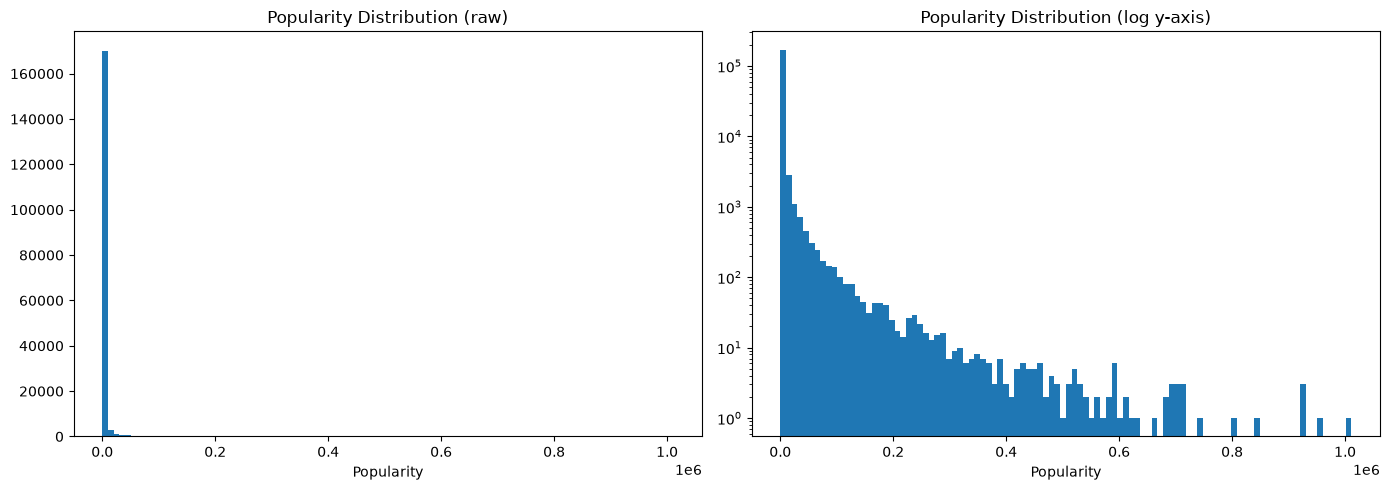

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['popularity'], bins=100)
axes[0].set_title('Popularity Distribution (raw)')
axes[0].set_xlabel('Popularity')

# log scale reveals the shape better when right-skewed
axes[1].hist(df[df['popularity'] > 0]['popularity'], bins=100)
axes[1].set_yscale('log')
axes[1].set_title('Popularity Distribution (log y-axis)')
axes[1].set_xlabel('Popularity')

plt.tight_layout()
plt.show()

In [64]:
# anime and manga have bigger audience than manhua or manhwa so the popularity binnging should be done bucket specific
print("=== POPULARITY by Bucket ===")
print(df.groupby('bucket')['popularity'].describe())

=== POPULARITY by Bucket ===
           count          mean           std  min    25%     50%     75%  \
bucket                                                                     
anime    24995.0  14282.244689  48750.940893  0.0  379.5  1401.0  6476.0   
manga   130403.0    742.466761   5037.155388  0.0   20.0    56.0   234.0   
manhua    5997.0    510.492580   1728.939222  0.0   37.0   105.0   345.0   
manhwa   15761.0   1235.958886   5859.095146  0.0   46.0   196.0   757.0   

              max  
bucket             
anime   1011211.0  
manga    322708.0  
manhua    37819.0  
manhwa   276923.0  


In [65]:
# Same check for average_score by bucket
print("=== AVERAGE_SCORE by Bucket ===")
print(df.groupby('bucket')['average_score'].describe())

=== AVERAGE_SCORE by Bucket ===
           count       mean        std  min   25%   50%   75%   max
bucket                                                             
anime    24995.0  50.571314  24.475877  0.0  46.0  58.0  67.0  91.0
manga   130403.0  15.455810  27.040613  0.0   0.0   0.0  41.0  92.0
manhua    5997.0  15.775554  26.726663  0.0   0.0   0.0  50.0  87.0
manhwa   15761.0  26.386651  31.297271  0.0   0.0   0.0  60.0  90.0


In [68]:
# Popularity by genre - requires exploding the comma-separated genres column first
df_genre_exploded = df.assign(genre_single=df['genres'].str.split(',')).explode('genre_single')
df_genre_exploded['genre_single'] = df_genre_exploded['genre_single'].str.strip()

print("=== POPULARITY by Genre ===")
print(df_genre_exploded.groupby('genre_single')['popularity'].describe().sort_values('mean', ascending=False).head(18))

=== POPULARITY by Genre ===
                 count          mean           std  min     25%     50%  \
genre_single                                                              
Thriller        2214.0  13072.326107  56177.388015  1.0   32.00   193.0   
Psychological   5825.0  11266.241373  47213.460417  0.0   82.00   416.0   
Mystery         7216.0   9086.529656  43050.498731  0.0   47.00   244.5   
Adventure      15734.0   8376.116182  39021.035096  0.0   98.00   581.0   
Action         27173.0   8107.875097  38459.980030  0.0   57.00   365.0   
Sci-Fi         10687.0   7081.597829  30401.457829  0.0   77.00   521.0   
Supernatural   17174.0   6909.109875  37608.108003  0.0   38.00   197.0   
Mecha           2737.0   6891.881257  30013.553918  2.0  204.00  1055.0   
Horror          5452.0   5726.389398  30528.821663  0.0   41.00   229.0   
Music           2104.0   5321.006179  22187.679229  0.0   78.75   422.0   
Ecchi           9728.0   5205.697882  22198.946006  0.0   53.00   353.0 

In [69]:
# Same for average_score by genre
print("=== AVERAGE_SCORE by Genre ===")
print(df_genre_exploded.groupby('genre_single')['average_score'].describe().sort_values('mean', ascending=False).head(18))

=== AVERAGE_SCORE by Genre ===
                 count       mean        std  min  25%   50%   75%   max
genre_single                                                            
Mahou Shoujo    1196.0  44.557692  30.263598  0.0  0.0  60.0  67.0  85.0
Mecha           2737.0  44.186335  28.993754  0.0  0.0  57.0  65.0  88.0
Psychological   5825.0  37.893734  33.125234  0.0  0.0  53.0  67.0  92.0
Adventure      15734.0  37.497903  31.857704  0.0  0.0  54.0  65.0  92.0
Sci-Fi         10687.0  36.416955  31.545315  0.0  0.0  53.0  64.0  91.0
Music           2104.0  36.194867  32.209993  0.0  0.0  50.0  66.0  88.0
Action         27173.0  32.769330  32.326347  0.0  0.0  47.0  63.0  92.0
Mystery         7216.0  30.912694  33.501178  0.0  0.0   0.0  65.0  92.0
Sports          3644.0  30.744512  32.681299  0.0  0.0   0.0  63.0  90.0
Ecchi           9728.0  30.398540  30.101873  0.0  0.0  45.0  59.0  87.0
Comedy         45774.0  29.455564  31.675143  0.0  0.0   0.0  61.0  91.0
Supernatural   17174

In [70]:
# Proposed bin boundaries based on percentiles (run after reviewing the above)
def assign_popularity_bin(value, p25, p50, p75, p90):
    if value < p25:
        return "Niche"
    elif value < p50:
        return "Known"
    elif value < p75:
        return "Popular"
    elif value < p90:
        return "Very Popular"
    else:
        return "Mainstream Hit"

p25 = df['popularity'].quantile(0.25)
p50 = df['popularity'].quantile(0.50)
p75 = df['popularity'].quantile(0.75)
p90 = df['popularity'].quantile(0.90)

df['popularity_bin'] = df['popularity'].apply(
    lambda x: assign_popularity_bin(x, p25, p50, p75, p90)
)

print(df['popularity_bin'].value_counts())

popularity_bin
Known             44904
Popular           44476
Niche             43443
Very Popular      26616
Mainstream Hit    17717
Name: count, dtype: int64


In [ ]:
# manga_mask = df['bucket'].isin(['manga', 'manhwa', 'manhua'])
print(df['year'].value_counts().sort_index())

year
1917.0        1
1924.0        1
1925.0        1
1926.0        1
1927.0        1
1928.0        3
1929.0        4
1930.0        3
1931.0       10
1932.0        4
1933.0        8
1934.0        6
1935.0        9
1936.0        6
1937.0        1
1938.0        1
1939.0        1
1940.0        1
1941.0        1
1942.0        2
1943.0        2
1945.0        1
1946.0        1
1947.0        1
1948.0        1
1949.0        1
1950.0        6
1951.0       10
1952.0        8
1953.0        7
1954.0       21
1955.0       17
1956.0       32
1957.0       29
1958.0       56
1959.0       43
1960.0       40
1961.0       43
1962.0       40
1963.0       49
1964.0       73
1965.0       85
1966.0       84
1967.0      116
1968.0      129
1969.0      145
1970.0      155
1971.0      132
1972.0      148
1973.0      156
1974.0      160
1975.0      200
1976.0      240
1977.0      307
1978.0      255
1979.0      277
1980.0      260
1981.0      301
1982.0      318
1983.0      331
1984.0      294
1985.0      403
198

checked for suspicious dips in manga/anime by year to see if the fault is in my script crashing but the distribution seems fair there is a decline post 2021 is due to anilist being a community driven service so it takes time to add newer titles and 2026 especially is incomplete 

# DATA CLEANING

In [ ]:
df.duplicated().any()
#There are duplicate entries possibly due to the script crashing in between and me running the script again

np.True_

In [ ]:
df.duplicated().sum()

np.int64(30537)

In [ ]:
# Removing duplicated data 
df = df.drop_duplicates(subset=['id'], keep='last')
print(df.shape)

(146350, 18)


In [ ]:
def synthesize_description(row) -> str:
    """
    Builds a minimal proxy description from structured fields
    when the real description is missing.
    """
    def safe_get(field):
        val = row[field]
        return "" if pd.isna(val) else str(val).strip()

    status = safe_get("status")
    bucket = safe_get("bucket")
    genres_raw = safe_get("genres")
    tags_raw = safe_get("tags")

    parts = []

    status_map = {
        "FINISHED": "finished",
        "RELEASING": "ongoing",
        "CANCELLED": "cancelled",
        "NOT_YET_RELEASED": "upcoming",
    }
    status_word = status_map.get(status, "")

    if status_word and bucket:
        parts.append(f"A {status_word} {bucket}")
    elif bucket:
        parts.append(f"A {bucket}")
    elif status_word:
        parts.append(f"A {status_word} title")
    else:
        parts.append("A title")

    genres = [g.strip() for g in genres_raw.split(",") if g.strip()]
    tags = [t.strip() for t in tags_raw.split(",") if t.strip()][:5]

    if genres and tags:
        parts.append(f"with genres including {', '.join(genres)}")
        parts.append(f"and themes such as {', '.join(tags)}")
    elif genres:
        parts.append(f"with genres including {', '.join(genres)}")
    elif tags:
        parts.append(f"with themes such as {', '.join(tags)}")
    else:
        parts.append("with no additional metadata available")

    return " ".join(parts) + "."

In [ ]:
# check to see if the transformation was applied here is an example of title with no description
empty_row = df[df['description'].isna()].iloc[10]
print(empty_row)

id                                                              186856
bucket                                                           anime
media_type                                                       ANIME
title                  Hito no Kurashi no Hyakumannen: Mani Mani March
native_title                                       人のくらしの百万年 マニ・マニ・マーチ
description                                                        NaN
country_of_origin                                                   JP
format                                                           MOVIE
status                                                        FINISHED
year                                                            1968.0
average_score                                                        0
popularity                                                          22
genres                                                             NaN
tags                                                               NaN
synony

In [ ]:
# Create mask BEFORE filling - captures which rows had missing descriptions
mask = df['description'].isna() | (df['description'].str.strip() == "")

# Tag synthetic rows as True/False boolean
df['description_is_synthetic'] = mask

# Now apply synthetic descriptions using the same mask
df.loc[mask, 'description'] = df[mask].apply(
    synthesize_description, axis=1
)

# Verify no nulls remain
print(f"Remaining missing descriptions: {df['description'].isna().sum()}")

# Quick sanity check - look at a few synthetic ones
print("\nSample synthetic descriptions:")
print(df[mask]['description'].head(5).to_string())

Remaining missing descriptions: 0

Sample synthetic descriptions:
5098      A finished anime with genres including Fantasy.
5101       A finished anime with genres including Action.
5117    A finished anime with no additional metadata a...
5129    A finished anime with no additional metadata a...
5151    A finished anime with genres including Slice o...


In [ ]:
# checking if the row is empty or if its filled with description now
df[df['id']==186856]['description']

5339    A finished anime with no additional metadata a...
Name: description, dtype: str

In [ ]:
print(f"Total titles: {df.shape[0]}")
print(f"Synthetic descriptions: {df['description_is_synthetic'].sum()}")
print(f"Real descriptions: {(~df['description_is_synthetic']).sum()}")
print(f"Remaining nulls in description: {df['description'].isna().sum()}")

Total titles: 146350
Synthetic descriptions: 32340
Real descriptions: 114010
Remaining nulls in description: 0


In [ ]:
# Save the clean dataset
df.to_csv("../data/raw_data_clean.csv", index=False)
print(f"Clean dataset saved: {df.shape[0]} unique titles")